## Exploring DMEPOS-By Supplier

This is the intital exploration and cleaning done before data from 2021-2023 are combined.

Note: This is for testing purposes only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
for f in Path("/dsa/groups/casestudycf25/team02/").iterdir():
    print(f.name)

DMEPOS_suplr_2021.csv
Medicare_Monthly_Enrollment_Jun_2025.csv
DMEPOS_suplr_2022.csv
DMEPOS_suplr_2023.csv
DMEPOS_Supplier_Service_2021.csv
DMEPOS_Supplier_Service_2022.csv
DMEPOS_Supplier_Service_2023.csv
LEIE_OIG_Exclusion_List.csv
mup_dme_ry25_p05_v10_dy21_rfrhpr.csv
mup_dme_ry25_p05_v10_dy21_rfrr.csv
mup_dme_ry25_p05_v10_dy22_rfrhpr.csv
mup_dme_ry25_p05_v10_dy22_rfrr.csv
mup_dme_ry25_p05_v10_dy23_rfrhpr.csv
mup_dme_ry25_p05_v10_dy23_rfrr.csv
RUCA2010zipcode.csv
Taxonomy Code List Dec 2023.csv
leie_with_null_npi_clean.csv
leie_with_valid_npi_clean.csv
medicare_enrollment_clean.csv
CMS_General_Payments_2021_2023_raw.csv
casestudycf25t02.sqlite.db
DMEPOS_Bene_only_suplr.csv
DMEPOS_rfrhpr_clean.csv
DMEPOS_rfrr_clean.csv
DMEPOS_cleaned_serv.csv
DMEPOS_cleaned_grouping.csv
OWNRSHP_PGYR2021_2023.csv
ownership_payment_clean.csv
DMEPOS_rfrhpr_clean_labeled.csv
DMEPOS_rfrr_clean_labeled.csv
general_payments_manufacturers_clean.csv
general_payments_providers_clean.csv
general_payments-sliced_

In [3]:
#Sincs its EDA, I will be exploring only the 2023 dataset.
header = pd.read_csv("/dsa/groups/casestudycf25/team02/DMEPOS_suplr_2023.csv", nrows=0).columns

for i in header:
    print(i)

Suplr_NPI
Suplr_Prvdr_Last_Name_Org
Suplr_Prvdr_First_Name
Suplr_Prvdr_MI
Suplr_Prvdr_Crdntls
Suplr_Prvdr_Ent_Cd
Suplr_Prvdr_St1
Suplr_Prvdr_St2
Suplr_Prvdr_City
Suplr_Prvdr_State_Abrvtn
Suplr_Prvdr_State_FIPS
Suplr_Prvdr_Zip5
Suplr_Prvdr_RUCA
Suplr_Prvdr_RUCA_Desc
Suplr_Prvdr_Cntry
Suplr_Prvdr_Spclty_Desc
Suplr_Prvdr_Spclty_Srce
Tot_Suplr_HCPCS_Cds
Tot_Suplr_Benes
Tot_Suplr_Clms
Tot_Suplr_Srvcs
Suplr_Sbmtd_Chrgs
Suplr_Mdcr_Alowd_Amt
Suplr_Mdcr_Pymt_Amt
Suplr_Mdcr_Stdzd_Pymt_Amt
DME_Sprsn_Ind
DME_Tot_Suplr_HCPCS_Cds
DME_Tot_Suplr_Benes
DME_Tot_Suplr_Clms
DME_Tot_Suplr_Srvcs
DME_Suplr_Sbmtd_Chrgs
DME_Suplr_Mdcr_Alowd_Amt
DME_Suplr_Mdcr_Pymt_Amt
DME_Suplr_Mdcr_Stdzd_Pymt_Amt
POS_Sprsn_Ind
POS_Tot_Suplr_HCPCS_Cds
POS_Tot_Suplr_Benes
POS_Tot_Suplr_Clms
POS_Tot_Suplr_Srvcs
POS_Suplr_Sbmtd_Chrgs
POS_Suplr_Mdcr_Alowd_Amt
POS_Suplr_Mdcr_Pymt_Amt
POS_Suplr_Mdcr_Stdzd_Pymt_Amt
Drug_Sprsn_Ind
Drug_Tot_Suplr_HCPCS_Cds
Drug_Tot_Suplr_Benes
Drug_Tot_Suplr_Clms
Drug_Tot_Suplr_Srvcs
Drug_Suplr_Sbmtd_C

In [4]:
#Loading the data and using polars to guess the data type of each attribute using the first 1000 rows of data
df = pd.read_csv("/dsa/groups/casestudycf25/team02/DMEPOS_suplr_2023.csv", nrows=None)

In [5]:
df.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,0.195980,0.105528,0.708543,0.673367,0.221106,0.20603,NaN,0.663317,NaN,1.016809
1,1003002254,Walgreen Co,NaN,NaN,NaN,O,5104 Bobby Hicks Hwy,NaN,Gray,TN,...,0.740000,0.240000,0.740000,0.860000,0.360000,NaN,0.0,0.340000,NaN,1.873065
2,1003004904,Texas Road Old Bridge Llc,NaN,NaN,NaN,O,1183 Englishtown Rd,NaN,Old Bridge,NJ,...,0.933333,NaN,1.000000,1.000000,NaN,NaN,0.0,NaN,0.0,1.091813
3,1003004938,"Cvs State Capital, L.L.C.",NaN,NaN,NaN,O,446 Sabattus St,NaN,Lewiston,ME,...,0.800000,NaN,0.771429,0.828571,NaN,NaN,0.0,0.400000,NaN,1.546691
4,1003007386,"The Giant Company, Llc",NaN,NaN,NaN,O,925 Norland Ave,NaN,Chambersburg,PA,...,0.978723,NaN,0.936170,1.000000,0.425532,NaN,NaN,0.510638,NaN,1.329664


In [6]:
#Shape of dataset
print(f"No. of data entries: {df.shape[0]}")
print(f"No. of attributes: {df.shape[1]}")

No. of data entries: 63988
No. of attributes: 93


In [7]:
#Looking into descriptive stats
df.describe()

,Suplr_NPI,Suplr_Prvdr_State_FIPS,Suplr_Prvdr_Zip5,Suplr_Prvdr_RUCA,Tot_Suplr_HCPCS_Cds,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Suplr_Sbmtd_Chrgs,Suplr_Mdcr_Alowd_Amt,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
count,6.398800e+04,63988.000000,63988.000000,63972.000000,63988.000000,58753.000000,63988.00000,6.398800e+04,6.398800e+04,6.398800e+04,...,50515.000000,26450.000000,54782.000000,55130.000000,36346.000000,19212.000000,31706.000000,44093.000000,17150.000000,63978.000000
mean,1.500483e+09,28.204804,48326.161890,1.953891,18.661655,183.411639,739.48817,4.259674e+04,5.963039e+05,2.595197e+05,...,0.719239,0.254192,0.818982,0.845565,0.363915,0.150175,0.004833,0.508691,0.076080,1.716353
std,2.882279e+08,15.730368,28479.987896,2.697715,23.691022,1566.322801,6999.16694,1.800364e+06,1.335126e+07,6.014246e+06,...,0.242340,0.120125,0.143236,0.149039,0.119439,0.094095,0.017048,0.143557,0.074743,0.679858
min,1.003000e+09,1.000000,603.000000,1.000000,1.000000,11.000000,11.00000,1.100000e+01,1.620000e+02,1.487000e+01,...,0.000000,0.000000,0.000000,0.186813,0.000000,0.000000,0.000000,0.000000,0.000000,0.313500
25%,1.255346e+09,13.000000,27103.000000,1.000000,8.000000,24.000000,50.00000,4.910000e+02,1.247359e+04,3.396597e+03,...,0.540457,0.183673,0.733333,0.757576,0.284953,0.105813,0.000000,0.407895,0.000000,1.306310
50%,1.497979e+09,28.000000,44679.500000,1.000000,12.000000,43.000000,113.00000,3.100000e+03,3.122726e+04,9.208600e+03,...,0.777778,0.244898,0.818182,0.843871,0.354167,0.150459,0.000000,0.490566,0.076433,1.603674
75%,1.750308e+09,42.000000,75062.000000,1.100000,18.000000,84.000000,237.00000,9.169250e+03,7.952356e+04,2.869021e+04,...,0.894737,0.317073,0.903226,0.928571,0.431225,0.198473,0.000000,0.589928,0.120000,1.964535
max,1.992999e+09,78.000000,99901.000000,99.000000,443.000000,122735.000000,907594.00000,3.497478e+08,2.721970e+09,7.036767e+08,...,2.042885,2.500000,3.035714,3.281625,1.813433,1.113314,1.107843,2.404110,0.733333,13.173802


In [8]:
#Data types
df.dtypes

Suplr_NPI                           int64
Suplr_Prvdr_Last_Name_Org          object
Suplr_Prvdr_First_Name             object
Suplr_Prvdr_MI                     object
Suplr_Prvdr_Crdntls                object
                                   ...   
Bene_CC_PH_Osteoporosis_V2_Pct    float64
Bene_CC_PH_Parkinson_V2_Pct       float64
Bene_CC_PH_Arthritis_V2_Pct       float64
Bene_CC_PH_Stroke_TIA_V2_Pct      float64
Bene_Avg_Risk_Scre                float64
Length: 93, dtype: object

In [9]:
#Carpentry
#Removing attributes that are not needed (for now)

rem_att = ['Drug_Sprsn_Ind', 'Drug_Tot_Suplr_HCPCS_Cds', 'Drug_Tot_Suplr_Benes', 
           'Drug_Tot_Suplr_Clms', 'Drug_Tot_Suplr_Srvcs', 'Drug_Suplr_Sbmtd_Chrgs', 
           'Drug_Suplr_Mdcr_Alowd_Amt', 'Drug_Suplr_Mdcr_Pymt_Amt', 
           'Drug_Suplr_Mdcr_Stdzd_Pymt_Amt', 'Bene_Avg_Age', 'Bene_Age_LT_65_Cnt', 
           'Bene_Age_65_74_Cnt', 'Bene_Age_75_84_Cnt', 'Bene_Age_GT_84_Cnt', 
           'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 
           'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 
           'Bene_Race_Othr_Cnt', 'Bene_Ndual_Cnt', 'Bene_Dual_Cnt',
           'Bene_CC_BH_ADHD_OthCD_V1_Pct', 'Bene_CC_BH_Alcohol_Drug_V1_Pct', 
           'Bene_CC_BH_Tobacco_V1_Pct', 'Bene_CC_BH_Alz_NonAlzdem_V2_Pct', 
           'Bene_CC_BH_Anxiety_V1_Pct', 'Bene_CC_BH_Bipolar_V1_Pct', 'Bene_CC_BH_Mood_V2_Pct', 
           'Bene_CC_BH_Depress_V1_Pct', 'Bene_CC_BH_PD_V1_Pct', 
           'Bene_CC_BH_PTSD_V1_Pct', 'Bene_CC_BH_Schizo_OthPsy_V1_Pct', 
           'Bene_CC_PH_Asthma_V2_Pct', 'Bene_CC_PH_Afib_V2_Pct', 'Bene_CC_PH_Cancer6_V2_Pct', 
           'Bene_CC_PH_CKD_V2_Pct', 'Bene_CC_PH_COPD_V2_Pct', 'Bene_CC_PH_Diabetes_V2_Pct', 
           'Bene_CC_PH_HF_NonIHD_V2_Pct', 'Bene_CC_PH_Hyperlipidemia_V2_Pct', 
           'Bene_CC_PH_Hypertension_V2_Pct', 'Bene_CC_PH_IschemicHeart_V2_Pct', 
           'Bene_CC_PH_Osteoporosis_V2_Pct', 'Bene_CC_PH_Parkinson_V2_Pct', 
           'Bene_CC_PH_Arthritis_V2_Pct', 'Bene_CC_PH_Stroke_TIA_V2_Pct']

df = df.drop(columns=rem_att)
df.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,POS_Sprsn_Ind,POS_Tot_Suplr_HCPCS_Cds,POS_Tot_Suplr_Benes,POS_Tot_Suplr_Clms,POS_Tot_Suplr_Srvcs,POS_Suplr_Sbmtd_Chrgs,POS_Suplr_Mdcr_Alowd_Amt,POS_Suplr_Mdcr_Pymt_Amt,POS_Suplr_Mdcr_Stdzd_Pymt_Amt,Bene_Avg_Risk_Scre
0,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,NaN,11.0,199.0,202.0,212.0,64112.0,50589.39,39364.54,37887.04,1.016809
1,1003002254,Walgreen Co,NaN,NaN,NaN,O,5104 Bobby Hicks Hwy,NaN,Gray,TN,...,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.873065
2,1003004904,Texas Road Old Bridge Llc,NaN,NaN,NaN,O,1183 Englishtown Rd,NaN,Old Bridge,NJ,...,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.091813
3,1003004938,"Cvs State Capital, L.L.C.",NaN,NaN,NaN,O,446 Sabattus St,NaN,Lewiston,ME,...,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.546691
4,1003007386,"The Giant Company, Llc",NaN,NaN,NaN,O,925 Norland Ave,NaN,Chambersburg,PA,...,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.329664


In [10]:
#Removing suppressed data
df = df[df['DME_Sprsn_Ind'].isna()]
df = df[df['POS_Sprsn_Ind'].isna()]
#Removing DME_Sprsn_Ind and POS_Sprsn_Ind as they are empty columns
df = df.drop(columns=['DME_Sprsn_Ind', 'POS_Sprsn_Ind'])
df.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,DME_Suplr_Mdcr_Stdzd_Pymt_Amt,POS_Tot_Suplr_HCPCS_Cds,POS_Tot_Suplr_Benes,POS_Tot_Suplr_Clms,POS_Tot_Suplr_Srvcs,POS_Suplr_Sbmtd_Chrgs,POS_Suplr_Mdcr_Alowd_Amt,POS_Suplr_Mdcr_Pymt_Amt,POS_Suplr_Mdcr_Stdzd_Pymt_Amt,Bene_Avg_Risk_Scre
0,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,0.00,11.0,199.0,202.0,212.0,64112.0,50589.39,39364.54,37887.04,1.016809
1,1003002254,Walgreen Co,NaN,NaN,NaN,O,5104 Bobby Hicks Hwy,NaN,Gray,TN,...,7826.44,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.873065
2,1003004904,Texas Road Old Bridge Llc,NaN,NaN,NaN,O,1183 Englishtown Rd,NaN,Old Bridge,NJ,...,920.03,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.091813
3,1003004938,"Cvs State Capital, L.L.C.",NaN,NaN,NaN,O,446 Sabattus St,NaN,Lewiston,ME,...,2828.95,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.546691
4,1003007386,"The Giant Company, Llc",NaN,NaN,NaN,O,925 Norland Ave,NaN,Chambersburg,PA,...,2119.66,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.329664


In [11]:
#Shape of dataset

print(f"No. of data entries: {df.shape[0]}")
print(f"No. of attributes: {df.shape[1]}")

#Around 17 thousand entries were removed, which is ~26% of the data. This is likely not a consistent value for the remaining datasets from the year 2021 and 2022 as the number of claims submitted differs from year to year for each supplier. So suppressed suppliers could also vary.

No. of data entries: 47154
No. of attributes: 42


In [12]:
#Checking for Null counts
nulls = df.isna().sum()

for i in nulls:
    print(i)

0
0
46727
46818
46786
0
0
41567
0
0
0
0
12
12
0
0
0
0
2684
0
0
0
0
0
0
0
3255
0
0
0
0
0
0
0
4129
0
0
0
0
0
0
6


In [13]:
numeric_cols = [
    "Tot_Suplr_HCPCS_Cds", "Tot_Suplr_Benes", "Tot_Suplr_Clms", "Tot_Suplr_Srvcs",
    "Suplr_Sbmtd_Chrgs", "Suplr_Mdcr_Alowd_Amt", "Suplr_Mdcr_Pymt_Amt", "Suplr_Mdcr_Stdzd_Pymt_Amt",
    "DME_Tot_Suplr_HCPCS_Cds", "DME_Tot_Suplr_Benes", "DME_Tot_Suplr_Clms", "DME_Tot_Suplr_Srvcs",
    "DME_Suplr_Sbmtd_Chrgs", "DME_Suplr_Mdcr_Alowd_Amt", "DME_Suplr_Mdcr_Pymt_Amt", "DME_Suplr_Mdcr_Stdzd_Pymt_Amt",
    "POS_Tot_Suplr_HCPCS_Cds", "POS_Tot_Suplr_Benes", "POS_Tot_Suplr_Clms", "POS_Tot_Suplr_Srvcs",
    "POS_Suplr_Sbmtd_Chrgs", "POS_Suplr_Mdcr_Alowd_Amt", "POS_Suplr_Mdcr_Pymt_Amt", "POS_Suplr_Mdcr_Stdzd_Pymt_Amt",
    "Bene_Avg_Risk_Scre"
]

df[numeric_cols] = df[numeric_cols].fillna(0)
#Since all the suppressed suppliers were removed, so it is safe to assume that null values likely indicate true zeros or missing data, making it kind of ideal to replace with 0 for general EDA.

In [14]:
#String columns
string_cols = df.select_dtypes(include="object").columns.tolist()
string_cols

['Suplr_Prvdr_Last_Name_Org',
 'Suplr_Prvdr_First_Name',
 'Suplr_Prvdr_MI',
 'Suplr_Prvdr_Crdntls',
 'Suplr_Prvdr_Ent_Cd',
 'Suplr_Prvdr_St1',
 'Suplr_Prvdr_St2',
 'Suplr_Prvdr_City',
 'Suplr_Prvdr_State_Abrvtn',
 'Suplr_Prvdr_RUCA_Desc',
 'Suplr_Prvdr_Cntry',
 'Suplr_Prvdr_Spclty_Desc',
 'Suplr_Prvdr_Spclty_Srce']

In [15]:
#Cleaning up strings variables
import re

for c in string_cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.lower()
        .str.replace(r"[^A-Za-z0-9\s]", "", regex=True)  # remove special characters
        .str.replace(r"\s+", "_", regex=True)            # replace spaces with underscores
        .fillna("na")                                    # replace nulls with 'na'
    )

df.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,DME_Suplr_Mdcr_Stdzd_Pymt_Amt,POS_Tot_Suplr_HCPCS_Cds,POS_Tot_Suplr_Benes,POS_Tot_Suplr_Clms,POS_Tot_Suplr_Srvcs,POS_Suplr_Sbmtd_Chrgs,POS_Suplr_Mdcr_Alowd_Amt,POS_Suplr_Mdcr_Pymt_Amt,POS_Suplr_Mdcr_Stdzd_Pymt_Amt,Bene_Avg_Risk_Scre
0,1003000399,reconstructive_hand_to_shoulder_of_indiana_llc,nan,nan,nan,o,13431_old_meridian_street,suite_225,carmel,in,...,0.00,11.0,199.0,202.0,212.0,64112.0,50589.39,39364.54,37887.04,1.016809
1,1003002254,walgreen_co,nan,nan,nan,o,5104_bobby_hicks_hwy,nan,gray,tn,...,7826.44,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.873065
2,1003004904,texas_road_old_bridge_llc,nan,nan,nan,o,1183_englishtown_rd,nan,old_bridge,nj,...,920.03,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.091813
3,1003004938,cvs_state_capital_llc,nan,nan,nan,o,446_sabattus_st,nan,lewiston,me,...,2828.95,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.546691
4,1003007386,the_giant_company_llc,nan,nan,nan,o,925_norland_ave,nan,chambersburg,pa,...,2119.66,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.329664


In [16]:
#There is only 12 suppliers with no RUCA code, we can exclude them for now.
df_clean = df[df['Suplr_Prvdr_RUCA'].notna()]
df_clean.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,DME_Suplr_Mdcr_Stdzd_Pymt_Amt,POS_Tot_Suplr_HCPCS_Cds,POS_Tot_Suplr_Benes,POS_Tot_Suplr_Clms,POS_Tot_Suplr_Srvcs,POS_Suplr_Sbmtd_Chrgs,POS_Suplr_Mdcr_Alowd_Amt,POS_Suplr_Mdcr_Pymt_Amt,POS_Suplr_Mdcr_Stdzd_Pymt_Amt,Bene_Avg_Risk_Scre
0,1003000399,reconstructive_hand_to_shoulder_of_indiana_llc,nan,nan,nan,o,13431_old_meridian_street,suite_225,carmel,in,...,0.00,11.0,199.0,202.0,212.0,64112.0,50589.39,39364.54,37887.04,1.016809
1,1003002254,walgreen_co,nan,nan,nan,o,5104_bobby_hicks_hwy,nan,gray,tn,...,7826.44,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.873065
2,1003004904,texas_road_old_bridge_llc,nan,nan,nan,o,1183_englishtown_rd,nan,old_bridge,nj,...,920.03,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.091813
3,1003004938,cvs_state_capital_llc,nan,nan,nan,o,446_sabattus_st,nan,lewiston,me,...,2828.95,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.546691
4,1003007386,the_giant_company_llc,nan,nan,nan,o,925_norland_ave,nan,chambersburg,pa,...,2119.66,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,1.329664


In [17]:
#Null counts for cleaned dataset and its shape
nulls = df_clean.isna().sum()

for i in nulls:
    print(i)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [18]:
print(f"No. of data entries: {df_clean.shape[0]}")
print(f"No. of attributes: {df_clean.shape[1]}")

No. of data entries: 47142
No. of attributes: 42


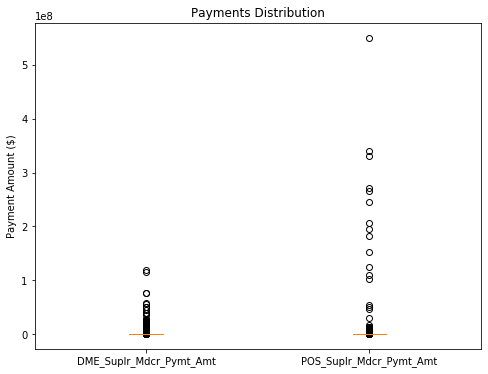

In [19]:
#Simple visuals

#Payments Distribution

payment_cols = ['DME_Suplr_Mdcr_Pymt_Amt', 'POS_Suplr_Mdcr_Pymt_Amt']

data = [df_clean[col].values for col in payment_cols]

plt.figure(figsize=(8,6))
plt.boxplot(data, labels=payment_cols)
plt.title('Payments Distribution')
plt.ylabel('Payment Amount ($)')
plt.show()

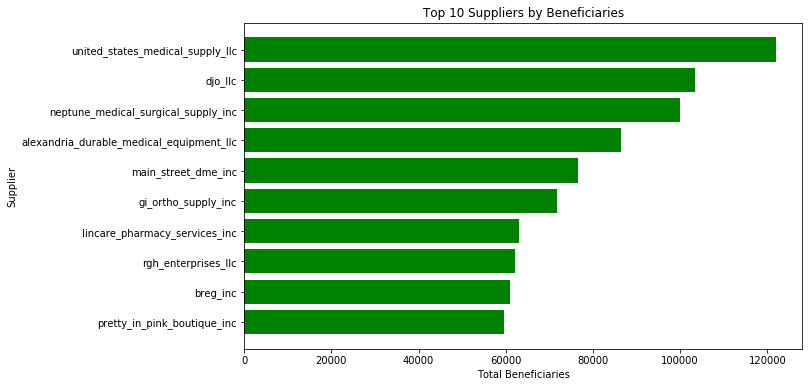

In [20]:
#Top 10 Suppliers by Beneficiaries

top_benes = df_clean[['Suplr_Prvdr_Last_Name_Org', 'Tot_Suplr_Benes']].sort_values(by='Tot_Suplr_Benes', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_benes['Suplr_Prvdr_Last_Name_Org'], top_benes['Tot_Suplr_Benes'], color='green')
plt.xlabel('Total Beneficiaries')
plt.ylabel('Supplier')
plt.title('Top 10 Suppliers by Beneficiaries')
plt.gca().invert_yaxis()  # largest on top
plt.show()


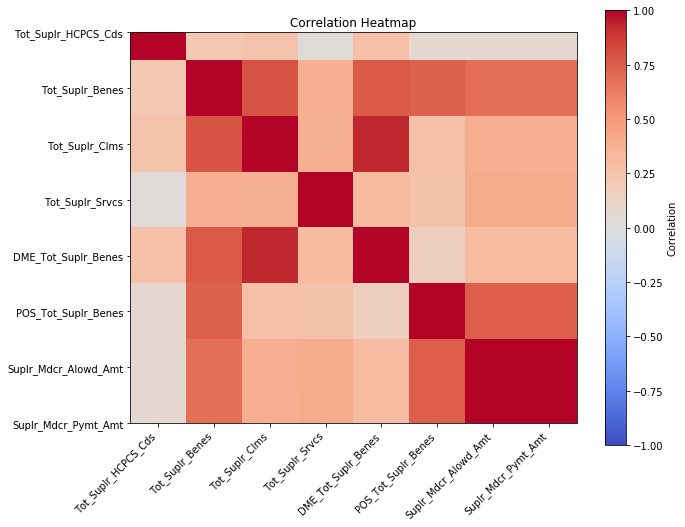

In [21]:
import numpy as np
# Building correlation matrix
numeric_cols = ['Tot_Suplr_HCPCS_Cds','Tot_Suplr_Benes','Tot_Suplr_Clms','Tot_Suplr_Srvcs',
                'DME_Tot_Suplr_Benes','POS_Tot_Suplr_Benes','Suplr_Mdcr_Alowd_Amt','Suplr_Mdcr_Pymt_Amt']


corr = df[numeric_cols].corr().values

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation Heatmap')
plt.show()

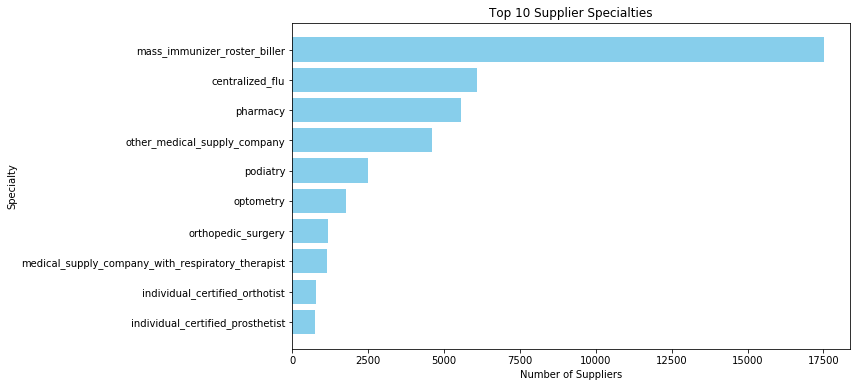

In [22]:
#Top 10 Supplier Specialties
top_specialties = (df_clean.groupby("Suplr_Prvdr_Spclty_Desc")["Suplr_NPI"].count().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,6))
plt.barh(top_specialties.index.tolist(), top_specialties.values.tolist(), color='skyblue')
plt.xlabel('Number of Suppliers')
plt.ylabel('Specialty')
plt.title('Top 10 Supplier Specialties')
plt.gca().invert_yaxis()
plt.show()
